In [200]:
# Import libraries

import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mafese import Data

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression  # Just for evaluating during feature selection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, roc_curve


from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [201]:
# Load Dataset
df = pd.read_csv('Credit_Card_Applications.csv')

# Optional: Drop 'id' column if present
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# Shuffle the data to mix Class 0 and Class 1
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare features and labels
X = df.drop('Class', axis=1)  # Features
y = df['Class']               # Labels

x_data = X #[:10001]
y_data = y #[:10001]


# Initialize mafese Data object
data = Data(x_data, y_data)

# Split the data
# (mafese automatically splits into training and testing sets)
data.split_train_test(test_size=0.3, random_state=42, inplace=True, stratify=y_data)  # You can adjust test_size and seed

# Scale the features
data.X_train, scaler_X = data.scale(data.X_train, scaling_methods=("standard", "minmax"))
data.X_test = scaler_X.transform(data.X_test)

# Encode the labels
data.y_train, scaler_y = data.encode_label(data.y_train)
data.y_test = scaler_y.transform(data.y_test)

# Print data shapes
print(f"Training Features Shape: {data.X_train.shape}")
print(f"Training Labels Shape: {data.y_train.shape}")
print(f"Testing Features Shape: {data.X_test.shape}")
print(f"Testing Labels Shape: {data.y_test.shape}")

Training Features Shape: (1854, 14)
Training Labels Shape: (1854,)
Testing Features Shape: (795, 14)
Testing Labels Shape: (795,)


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning:

X has feature names, but StandardScaler was fitted without feature names



In [202]:
data.y_test

array([0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,

## Exploratory Data Analysis

In [203]:
# load the dataset (read the CSV file)
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,1,22.25,0.46,2,4,4,0.125,0,0,0,1,2,280,56,0
1,1,19.42,6.50,2,9,8,1.460,1,1,7,0,2,80,2955,1
2,0,38.75,1.50,2,1,1,0.000,0,0,0,0,2,76,1,0
3,1,60.08,14.50,2,1,1,18.000,1,1,15,1,2,0,1001,1
4,0,22.42,11.25,1,14,8,0.750,1,1,4,0,2,0,322,1


In [204]:
# Show the dataset information, including data types and missing values
df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000
mean,0.675727,31.640393,4.788754,1.772744,7.395621,4.673462,2.249468,0.527746,0.429596,2.326161,0.461306,1.927520,183.892412,989.089090,0.449981
std,0.468191,12.049309,4.968918,0.428053,3.684980,1.989260,3.401925,0.499324,0.495112,4.571197,0.498595,0.294771,173.592382,5403.767653,0.497586
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.000000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.580000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,160.000000,5.000000,0.000000
75%,1.000000,37.500000,7.500000,2.000000,10.000000,5.000000,2.710000,1.000000,1.000000,3.000000,1.000000,2.000000,272.000000,401.000000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.000000,1.000000,3.000000,2000.000000,100001.000000,1.000000


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2649 entries, 0 to 2648
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      2649 non-null   int64  
 1   A2      2649 non-null   float64
 2   A3      2649 non-null   float64
 3   A4      2649 non-null   int64  
 4   A5      2649 non-null   int64  
 5   A6      2649 non-null   int64  
 6   A7      2649 non-null   float64
 7   A8      2649 non-null   int64  
 8   A9      2649 non-null   int64  
 9   A10     2649 non-null   int64  
 10  A11     2649 non-null   int64  
 11  A12     2649 non-null   int64  
 12  A13     2649 non-null   int64  
 13  A14     2649 non-null   int64  
 14  Class   2649 non-null   int64  
dtypes: float64(3), int64(12)
memory usage: 310.6 KB


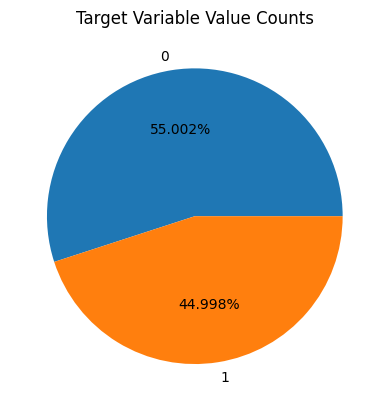

In [206]:
labels = df['Class'].unique()
sizes = df.Class.value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

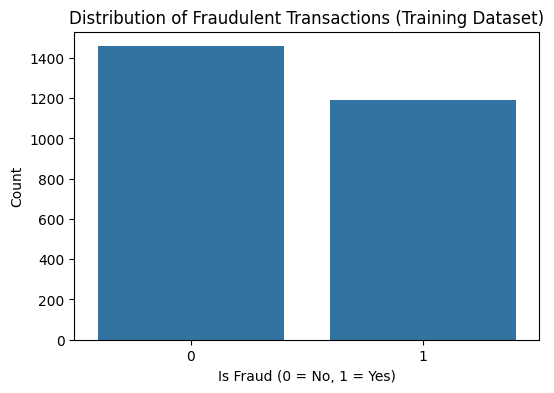

In [207]:
# Distribution of the target variable ('is_fraud') in the training dataset
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Fraudulent Transactions (Training Dataset)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

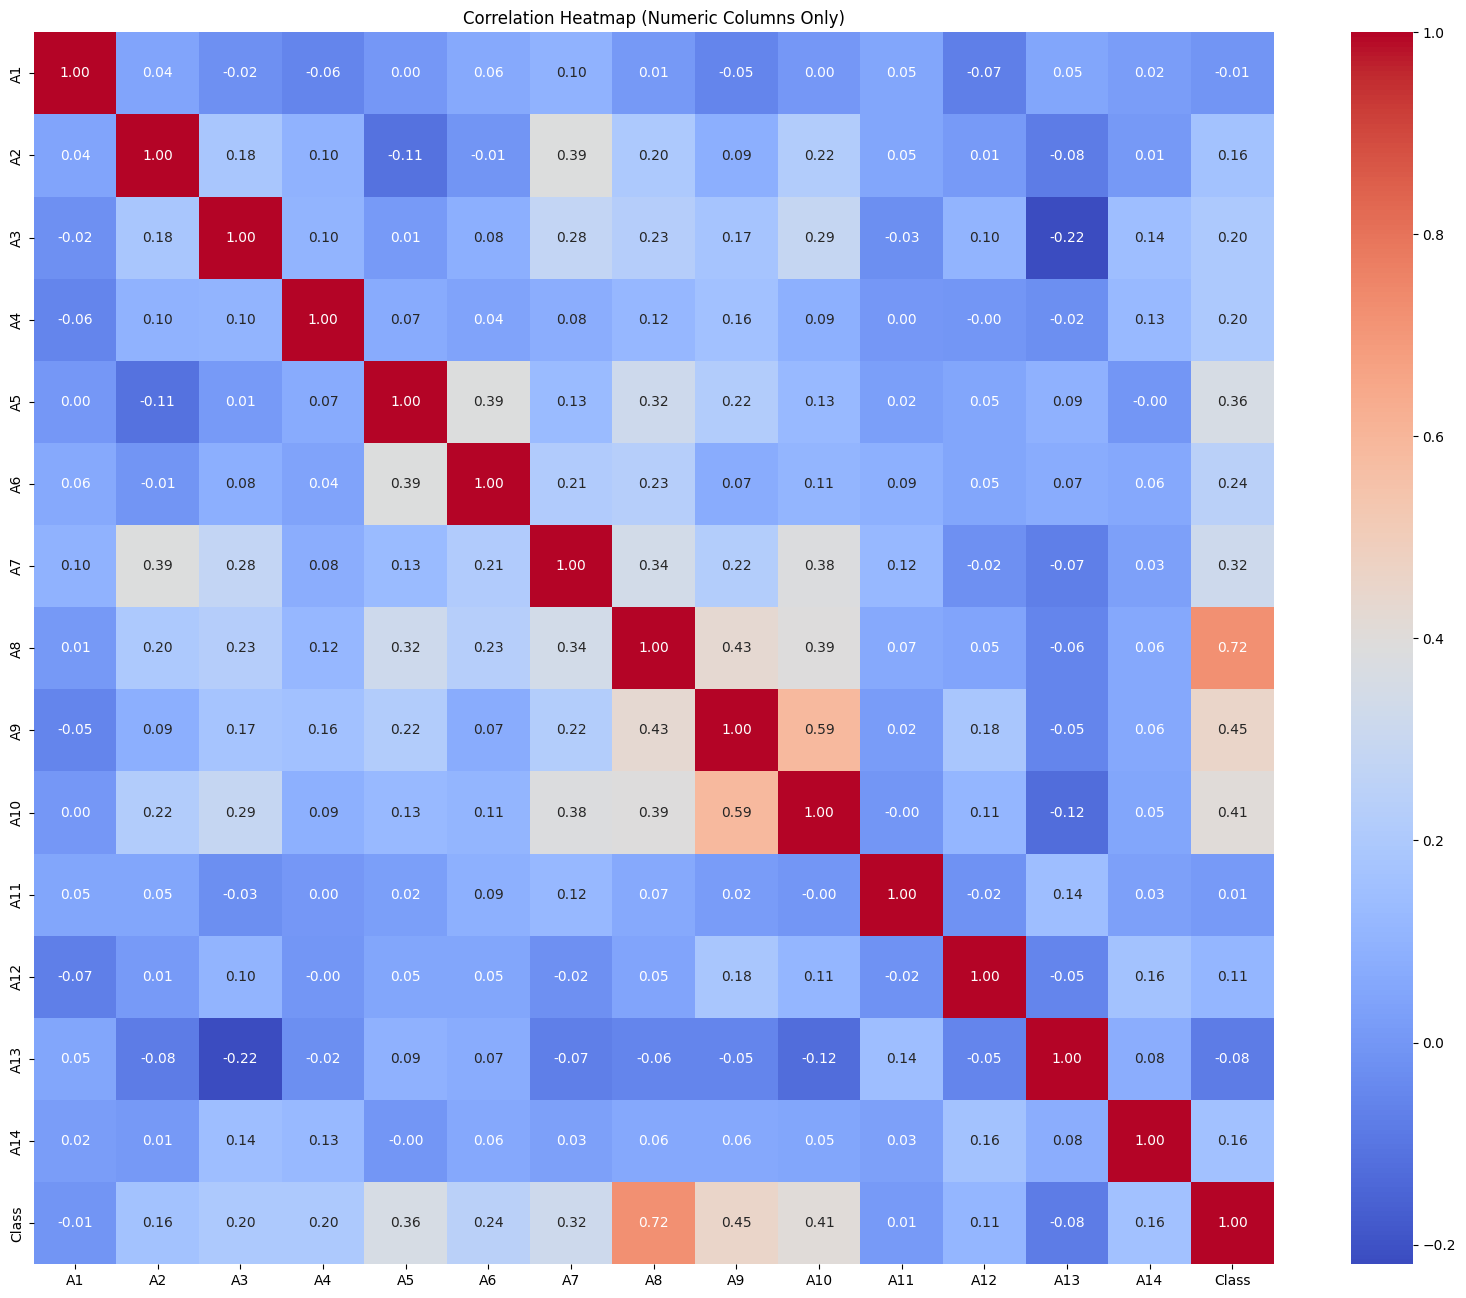

In [208]:
# Select only numeric columns for correlation analysis
numeric_data = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

In [209]:
data.X_train

array([[1.        , 0.37097744, 0.02517857, ..., 0.5       , 0.1125    ,
        0.005     ],
       [1.        , 0.61774436, 0.55357143, ..., 0.5       , 0.076     ,
        0.0013    ],
       [0.        , 0.38090226, 0.14285714, ..., 0.5       , 0.24      ,
        0.        ],
       ...,
       [0.        , 0.13789474, 0.04464286, ..., 0.5       , 0.06      ,
        0.00809   ],
       [1.        , 0.14165414, 0.39732143, ..., 0.5       , 0.05      ,
        0.        ],
       [0.        , 0.2443609 , 0.18892857, ..., 0.5       , 0.0495    ,
        0.005     ]])

In [210]:
X

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,1,22.25,0.460,2,4,4,0.125,0,0,0,1,2,280,56
1,1,19.42,6.500,2,9,8,1.460,1,1,7,0,2,80,2955
2,0,38.75,1.500,2,1,1,0.000,0,0,0,0,2,76,1
3,1,60.08,14.500,2,1,1,18.000,1,1,15,1,2,0,1001
4,0,22.42,11.250,1,14,8,0.750,1,1,4,0,2,0,322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2644,0,26.17,2.000,2,5,3,0.000,0,0,0,1,2,276,2
2645,1,38.17,10.125,2,14,4,2.500,1,1,6,0,2,520,197
2646,1,67.75,5.500,2,10,9,13.000,1,1,1,1,2,0,1
2647,1,21.83,11.000,2,14,4,0.290,1,1,6,0,2,121,1


## Initializing The Enhanced BBOA Algorithm and Feature Selection Model

In [211]:
# ------------ Updated Enhanced BBOA Feature Selector ---------------- #

class EnhancedBBOAFeatureSelector:
    def __init__(self,
                 n_agents=20,
                 max_iter=30,
                 initial_exploration_rate=0.5,
                 r_min=0.1,
                 r_max=1.0,
                 boundaries=(0, 1),
                 classifier=None,
                 cv_folds=5,
                 save_dir="./enhanced_bboa_results",
                 random_state=None,
                 verbose=True,
                 plot_convergence=True):
        
        self.n_agents = n_agents
        self.max_iter = max_iter
        self.initial_exploration_rate = initial_exploration_rate
        self.r_min = r_min
        self.r_max = r_max
        self.boundaries = boundaries
        self.classifier = classifier
        self.cv_folds = cv_folds
        self.save_dir = save_dir
        self.random_state = random_state
        self.verbose = verbose

        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        self.history = []

    def _initialize_population(self, dim):
        return np.random.uniform(self.boundaries[0], self.boundaries[1], (self.n_agents, dim))

    def _evaluate_fitness(self, population, X, y):
        fitness = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            mask = population[i] > 0.5
            if np.sum(mask) == 0:
                fitness[i] = np.inf  # Penalize invalid solutions
                continue

            X_selected = X[:, mask]
            scores = cross_val_score(self.classifier, X_selected, y, cv=self.cv_folds)
            fitness[i] = 1.0 - np.mean(scores)  # Lower fitness is better
        return fitness

    def _calculate_diversity(self, population):
        return np.mean(np.std(population, axis=0))

    def _select_best_and_worst(self, population, fitness):
        best_idx = np.argmin(fitness)
        worst_idx = np.argmax(fitness)
        return population[best_idx], population[worst_idx]

    def _enhance_exploration(self, population, best_bear, worst_bear, alpha_k, r_k, theta_k):
        new_population = np.copy(population)
        for i in range(self.n_agents):
            rand_vector = np.random.uniform(-1, 1, size=population.shape[1])
            if 0 < theta_k <= 1/3:
                new_population[i] += alpha_k * rand_vector * r_k
            elif 1/3 < theta_k <= 2/3:
                new_population[i] += (alpha_k / 2) * rand_vector * r_k
            else:
                new_population[i] += (alpha_k / 5) * rand_vector * r_k

            new_population[i] = np.clip(new_population[i], self.boundaries[0], self.boundaries[1])
        return new_population

    def _adaptive_sniffing(self, population, fitness, diversity, diversity_threshold=0.1):
        new_population = np.copy(population)
        for i in range(self.n_agents):
            mate_idx = np.random.choice([idx for idx in range(self.n_agents) if idx != i])
            if diversity < diversity_threshold:
                if fitness[i] > fitness[mate_idx]:
                    new_population[i] = (population[i] + population[mate_idx]) / 2
            else:
                rand_factor = np.random.uniform(0, 1)
                new_population[i] = rand_factor * population[i] + (1 - rand_factor) * population[mate_idx]
            
            new_population[i] = np.clip(new_population[i], self.boundaries[0], self.boundaries[1])
        return new_population

    def fit(self, X, y):
        """
        Fit the Enhanced BBOA algorithm to select features.
        """
        dim = X.shape[1]
        P = self._initialize_population(dim)
        fitness = self._evaluate_fitness(P, X, y)
    
        f_best = np.min(fitness)
        P_best = P[np.argmin(fitness)]
    
        for k in range(1, self.max_iter + 1):
            start_time = time.time()  # Start timing the epoch
            theta_k = k / self.max_iter
            alpha_k = self.initial_exploration_rate * (1 - theta_k)
            r_k = self.r_min + (self.r_max - self.r_min) * (1 - theta_k)
    
            # Step 1: Enhance Exploration
            best_bear, worst_bear = self._select_best_and_worst(P, fitness)
            new_P = self._enhance_exploration(P, best_bear, worst_bear, alpha_k, r_k, theta_k)
            new_fitness = self._evaluate_fitness(new_P, X, y)
    
            # Step 2: Greedy Replacement after Exploration
            for i in range(self.n_agents):
                if new_fitness[i] < fitness[i]:  # lower fitness is better
                    P[i] = new_P[i]
                    fitness[i] = new_fitness[i]
    
            # Step 3: Update Best
            current_best_idx = np.argmin(fitness)
            if fitness[current_best_idx] < f_best:
                f_best = fitness[current_best_idx]
                P_best = P[current_best_idx]
    
            # Step 4: Calculate Diversity
            diversity = self._calculate_diversity(P)
    
            # Step 5: Adaptive Sniffing
            new_P = self._adaptive_sniffing(P, fitness, diversity)
            new_fitness = self._evaluate_fitness(new_P, X, y)
    
            # Step 6: Greedy Replacement after Sniffing
            for i in range(self.n_agents):
                if new_fitness[i] < fitness[i]:
                    P[i] = new_P[i]
                    fitness[i] = new_fitness[i]
    
            # Step 7: Update Best Again
            current_best_idx = np.argmin(fitness)
            if fitness[current_best_idx] < f_best:
                f_best = fitness[current_best_idx]
                P_best = P[current_best_idx]
    
            self.history.append(f_best)
            
            # Calculate elapsed time
            elapsed_time = time.time() - start_time
    
            if self.verbose:
                print(f"Iteration {k}/{self.max_iter}, Best Fitness: {f_best:.6f}, Diversity: {diversity:.6f}, Time: {elapsed_time:.2f}s")
    
        self.best_fitness = f_best
        self.best_agent = P_best
        self._save_best_agent()
    
        if self.plot_convergence:
            self.plot_convergence()


    def transform(self, X):
        """
        Transform the dataset using the selected features.

        Parameters:
            X : ndarray
                Input dataset of shape (n_samples, n_features).

        Returns:
            X_selected : ndarray
                Dataset with selected features only.
        """
        if self.best_agent is None:
            raise Exception("Model has not been fitted yet. Call `fit` first.")
            
        mask = self.best_agent > 0.5
        return X[:, mask]

    def fit_transform(self, X, y):
        """
        Fit the model and transform the dataset.

        Parameters:
            X : ndarray
                Input dataset of shape (n_samples, n_features).

        Returns:
            X_selected : ndarray
                Dataset with selected features.
        """
        self.fit(X, y)
        return self.transform(X)

    def _save_best_agent(self):
        np.save(os.path.join(self.save_dir, "best_agent.npy"), self.best_agent)
        summary = {
            "selected_features_count": int(np.sum(self.best_agent > 0.5)),
            "total_features": int(len(self.best_agent)),
            "best_fitness_score": float(self.best_fitness),
            "cv_folds": self.cv_folds
        }
        with open(os.path.join(self.save_dir, "summary.json"), "w") as f:
            json.dump(summary, f, indent=4)

    def get_selected_indices(self):
        return np.where(self.best_agent > 0.5)[0]

    def plot_convergence(self):
        """
        Plot the convergence curve of the fitness over iterations.
        """
        plt.figure(figsize=(8, 5))
        plt.plot(self.history, label="Best Fitness")
        plt.xlabel("Iteration")
        plt.ylabel("Fitness")
        plt.title("Convergence Curve")
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(self.save_dir, "fitness_curve.png"))
        plt.show()

Iteration 1/30, Best Fitness: 0.133226, Diversity: 0.295042, Time: 0.31s
Iteration 2/30, Best Fitness: 0.133226, Diversity: 0.300342, Time: 0.34s
Iteration 3/30, Best Fitness: 0.133226, Diversity: 0.271001, Time: 0.34s
Iteration 4/30, Best Fitness: 0.130525, Diversity: 0.245895, Time: 0.35s
Iteration 5/30, Best Fitness: 0.130525, Diversity: 0.217769, Time: 0.39s
Iteration 6/30, Best Fitness: 0.130525, Diversity: 0.206915, Time: 0.36s
Iteration 7/30, Best Fitness: 0.130525, Diversity: 0.176245, Time: 0.34s
Iteration 8/30, Best Fitness: 0.128367, Diversity: 0.174165, Time: 0.35s
Iteration 9/30, Best Fitness: 0.128367, Diversity: 0.157568, Time: 0.41s
Iteration 10/30, Best Fitness: 0.128367, Diversity: 0.151560, Time: 0.35s
Iteration 11/30, Best Fitness: 0.128367, Diversity: 0.140222, Time: 0.33s
Iteration 12/30, Best Fitness: 0.128367, Diversity: 0.140222, Time: 0.32s
Iteration 13/30, Best Fitness: 0.128367, Diversity: 0.141216, Time: 0.32s
Iteration 14/30, Best Fitness: 0.128367, Divers

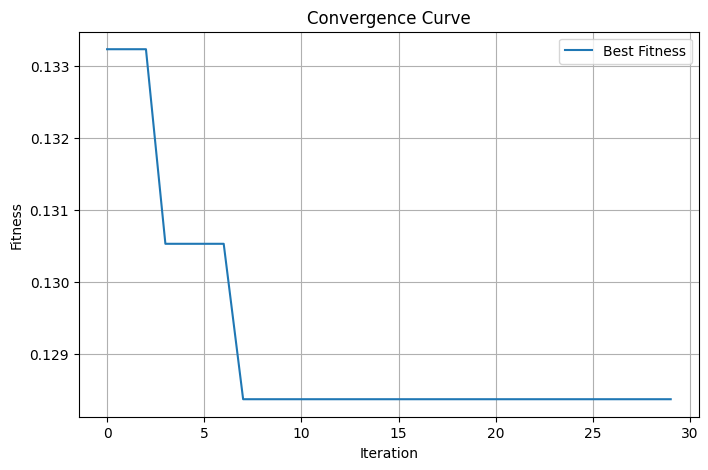

Original features: 14
Selected features: 11


In [212]:
# Initialize Enhanced BBOA Feature Selector
enhanced_bboa_selector = EnhancedBBOAFeatureSelector(
    n_agents=20,
    max_iter=30,
    initial_exploration_rate=0.5,
    classifier=LogisticRegression(),
    cv_folds=5,
    save_dir="./enhanced_bboa_results",
    random_state=42
)

# Fit and transform your data
X_train_selected = enhanced_bboa_selector.fit_transform(data.X_train, data.y_train)

# Reduce X_test as well
selected_indices = enhanced_bboa_selector.get_selected_indices()
X_test_selected = data.X_test[:, selected_indices]

print(f"Original features: {data.X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

In [213]:
X_train_selected.shape[1]

11

In [214]:
X_test_selected

array([[1.        , 0.26796992, 0.01339286, ..., 0.        , 0.464     ,
        0.        ],
       [1.        , 0.21428571, 0.07142857, ..., 0.5       , 0.0905    ,
        0.        ],
       [1.        , 0.12406015, 0.27982143, ..., 0.5       , 0.092     ,
        0.        ],
       ...,
       [1.        , 0.31578947, 0.53571429, ..., 0.5       , 0.        ,
        0.00134   ],
       [1.        , 0.08646617, 0.34232143, ..., 0.5       , 0.04      ,
        0.0035    ],
       [0.        , 0.26796992, 0.40178571, ..., 0.5       , 0.092     ,
        0.052     ]])

In [215]:
# --------- Simple SNN Model for Classification ------------- #

# -------- Surrogate Function --------
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input >= 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # surrogate gradient: d(ReLU)/dx (approximate)
        surrogate_grad = torch.sigmoid(5 * input) * (1 - torch.sigmoid(5 * input))
        return grad_input * surrogate_grad

surrogate_spike_fn = SurrogateSpike.apply

# -------- Updated SNNLayer --------
class SNNLayer(nn.Module):
    def __init__(self, in_features, out_features, threshold=1.0, decay=0.9):
        super(SNNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.threshold = threshold
        self.decay = decay
        self.mem = None

    def forward(self, x):
        if self.mem is None:
            self.mem = torch.zeros(x.size(0), self.fc.out_features, device=x.device)

        current = self.fc(x)
        self.mem = self.mem * self.decay + current
        spike = surrogate_spike_fn(self.mem - self.threshold)
        self.mem = self.mem * (1 - spike)  # reset after spike
        return spike

    def reset(self):
        self.mem = None

# -------- Updated SNNClassifier --------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, threshold=1.0):
        super(SNNClassifier, self).__init__()
        self.snn1 = SNNLayer(input_dim, hidden_dim, threshold=threshold)
        self.snn2 = SNNLayer(hidden_dim, output_dim, threshold=threshold)

    def forward(self, x, time_steps=20):
        out_spikes = torch.zeros(x.size(0), self.snn2.fc.out_features, device=x.device)
        for t in range(time_steps):
            spike1 = self.snn1(x)
            spike2 = self.snn2(spike1)
            out_spikes += spike2
        return out_spikes  # output spike counts (higher means more confident)

    def reset(self):
        self.snn1.reset()
        self.snn2.reset()

# -------- Updated SNNTrainer --------
class SNNTrainer:
    def __init__(self, model, lr=1e-3, epochs=30, batch_size=32, device=None):
        self.model = model
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.losses = []

    def fit(self, X_train, y_train):
        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.long)

        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(self.epochs):
            
            start_time = time.time()
            
            self.model.train()
            epoch_loss = 0
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                self.model.reset()
                out = self.model(xb)

                loss = criterion(out, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(loader)
            self.losses.append(avg_epoch_loss)

             # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Epoch {epoch+1}/{self.epochs}, Loss: {avg_epoch_loss:.4f}, Time: {elapsed_time:.2f}s")

    def plot_training_loss(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.losses, label="Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.legend()
        plt.grid()
        plt.show()

    def evaluate(self, X_test, y_test):
        self.model.eval()
        X_test = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(self.device)
    
        self.model.reset()
        out = self.model(X_test)  # raw logits or probabilities
        preds = torch.argmax(out, dim=1)
    
        y_true = y_test.cpu().numpy()
        y_pred = preds.cpu().numpy()
    
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")
    
        # MCC
        mcc = matthews_corrcoef(y_true, y_pred)
    
        # AUC-ROC Score (binary or one-vs-rest)
        if out.shape[1] == 2:
            probs = torch.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
            auc_roc = roc_auc_score(y_true, probs)
            
            # Plot ROC curve
            fpr, tpr, _ = roc_curve(y_true, probs)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {auc_roc:.4f}')
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            auc_roc = roc_auc_score(y_true, out.detach().cpu().numpy(), multi_class='ovr', average='weighted')
    
        # Print Metrics
        print("\nClassification Report:\n", classification_report(y_true, y_pred))
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("MCC:", mcc)
        print("AUC-ROC Score:", auc_roc)
    
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    
        return acc, precision, recall, f1, mcc, auc_roc

    def save_model(self, path="./snn_model.pth"):
        torch.save(self.model.state_dict(), path)

    def load_model(self, path="./snn_model.pth"):
        self.model.load_state_dict(torch.load(path, map_location=self.device))

Epoch 1/30, Loss: 0.4483, Time: 0.28s
Epoch 2/30, Loss: 0.3553, Time: 0.24s
Epoch 3/30, Loss: 0.3375, Time: 0.24s
Epoch 4/30, Loss: 0.3232, Time: 0.24s
Epoch 5/30, Loss: 0.3052, Time: 0.24s
Epoch 6/30, Loss: 0.2958, Time: 0.24s
Epoch 7/30, Loss: 0.2993, Time: 0.24s
Epoch 8/30, Loss: 0.2849, Time: 0.24s
Epoch 9/30, Loss: 0.2814, Time: 0.24s
Epoch 10/30, Loss: 0.2775, Time: 0.24s
Epoch 11/30, Loss: 0.2727, Time: 0.24s
Epoch 12/30, Loss: 0.2767, Time: 0.24s
Epoch 13/30, Loss: 0.2615, Time: 0.24s
Epoch 14/30, Loss: 0.2500, Time: 0.25s
Epoch 15/30, Loss: 0.2492, Time: 0.24s
Epoch 16/30, Loss: 0.2442, Time: 0.24s
Epoch 17/30, Loss: 0.2266, Time: 0.24s
Epoch 18/30, Loss: 0.2329, Time: 0.24s
Epoch 19/30, Loss: 0.2381, Time: 0.25s
Epoch 20/30, Loss: 0.2278, Time: 0.24s
Epoch 21/30, Loss: 0.2301, Time: 0.24s
Epoch 22/30, Loss: 0.2140, Time: 0.24s
Epoch 23/30, Loss: 0.2202, Time: 0.24s
Epoch 24/30, Loss: 0.2125, Time: 0.24s
Epoch 25/30, Loss: 0.2174, Time: 0.24s
Epoch 26/30, Loss: 0.2084, Time: 0

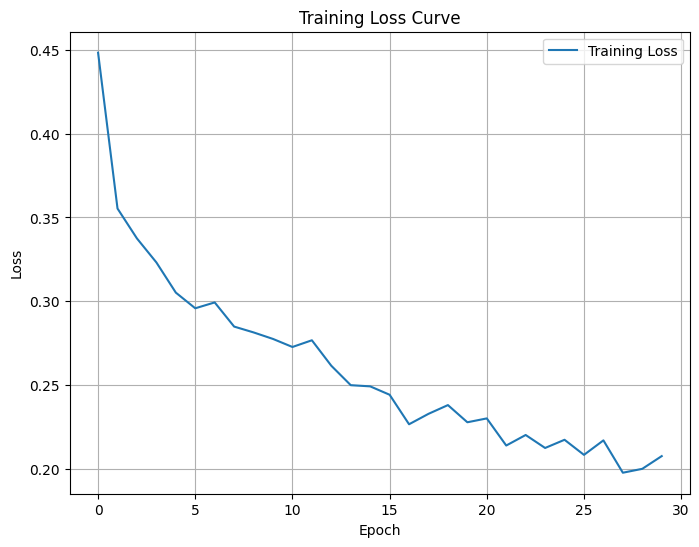

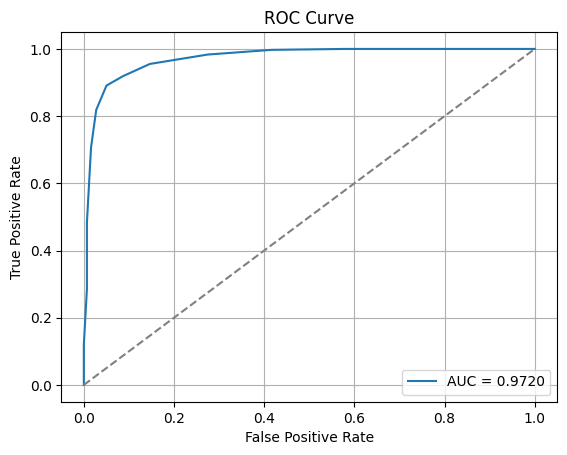


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       437
           1       0.94      0.89      0.91       358

    accuracy                           0.92       795
   macro avg       0.92      0.92      0.92       795
weighted avg       0.92      0.92      0.92       795

Accuracy: 0.9232704402515723
Precision: 0.9237277713576844
Recall: 0.9232704402515723
F1 Score: 0.9230693791854839
MCC: 0.8451378780103258
AUC-ROC Score: 0.9720095112690641


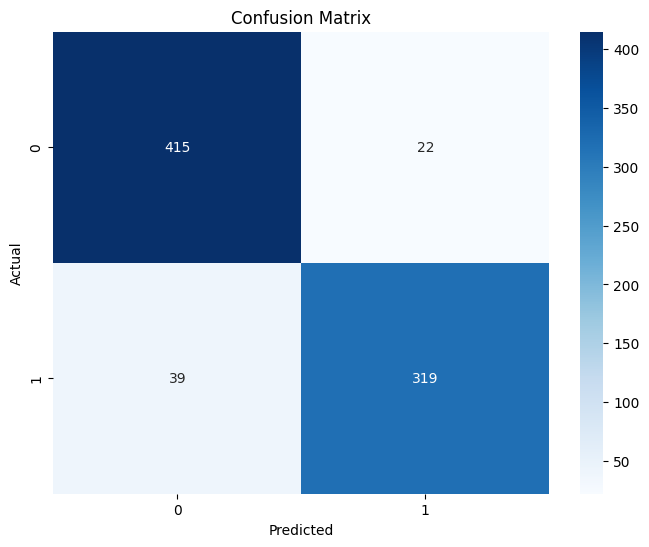

In [216]:
# Initialize
input_dim = X_train_selected.shape[1]
hidden_dim = 128
output_dim = len(np.unique(data.y_train))  # number of classes

snn_model = SNNClassifier(input_dim, hidden_dim, output_dim)

# Train
trainer = SNNTrainer(snn_model, lr=0.001, epochs=30, batch_size=32)
trainer.fit(X_train_selected, data.y_train)

# Plot Training Loss
trainer.plot_training_loss()

# Evaluate
trainer.evaluate(X_test_selected, data.y_test)

# Save Model
trainer.save_model("./bboa_selected_snn_model.pth")